# Counter-Trend

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None) # Show all columns when printing a dataframe

## Prepare data

In [31]:
df = pd.read_excel('/home/jlaw/projects/python/roboAdvisorSystTrading/notebooks/data/COUNTER_TREND_DATA.xlsx', header=1)
df = df.iloc[2:] # Remove rows where Hedge hasn't computed yet
df['Date'] = pd.to_datetime(df['#Date'], format='%Y%m%d')
df.head()

,#Date,Open,High,Low,Close,NC,PC(%),Roll,DayRange,Av20R,PrvHiWRoll,HitLevel,Hit?,HitAt,ExitPr,Ret2C,BuyNhold,EQ_Graph,EQ_BuyNHold,Unnamed: 19,Unnamed: 20,Strat_Up,Calculate these values!,Unnamed: 23,Date
2,20030703,986.20001,994.20001,976.0,982.50000,-10.40002,-1.047439,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,RETURNS,MktUp,Mkt_Dn,2003-07-03
3,20030707,992.50000,1005.00000,992.5,1002.50000,20.00000,2.035623,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Strat_Up,Calculate these values!,NaN,2003-07-07
4,20030708,1000.79999,1008.50000,997.5,1007.59998,5.09998,0.508726,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Strat_Dn,NaN,NaN,2003-07-08
5,20030709,1005.00000,1009.79999,996.5,1000.90002,-6.69995,-0.664942,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2003-07-09
6,20030710,994.50000,996.29999,982.0,988.70001,-12.20001,-1.218904,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2003-07-10


In [44]:
# add Roll to previous day's High
df['DayRange'] = df['High'] + df['Roll'].shift(1) - df['Low']

df['Av20R'] = df['DayRange'].rolling(window=20).mean()

# df.head(51)

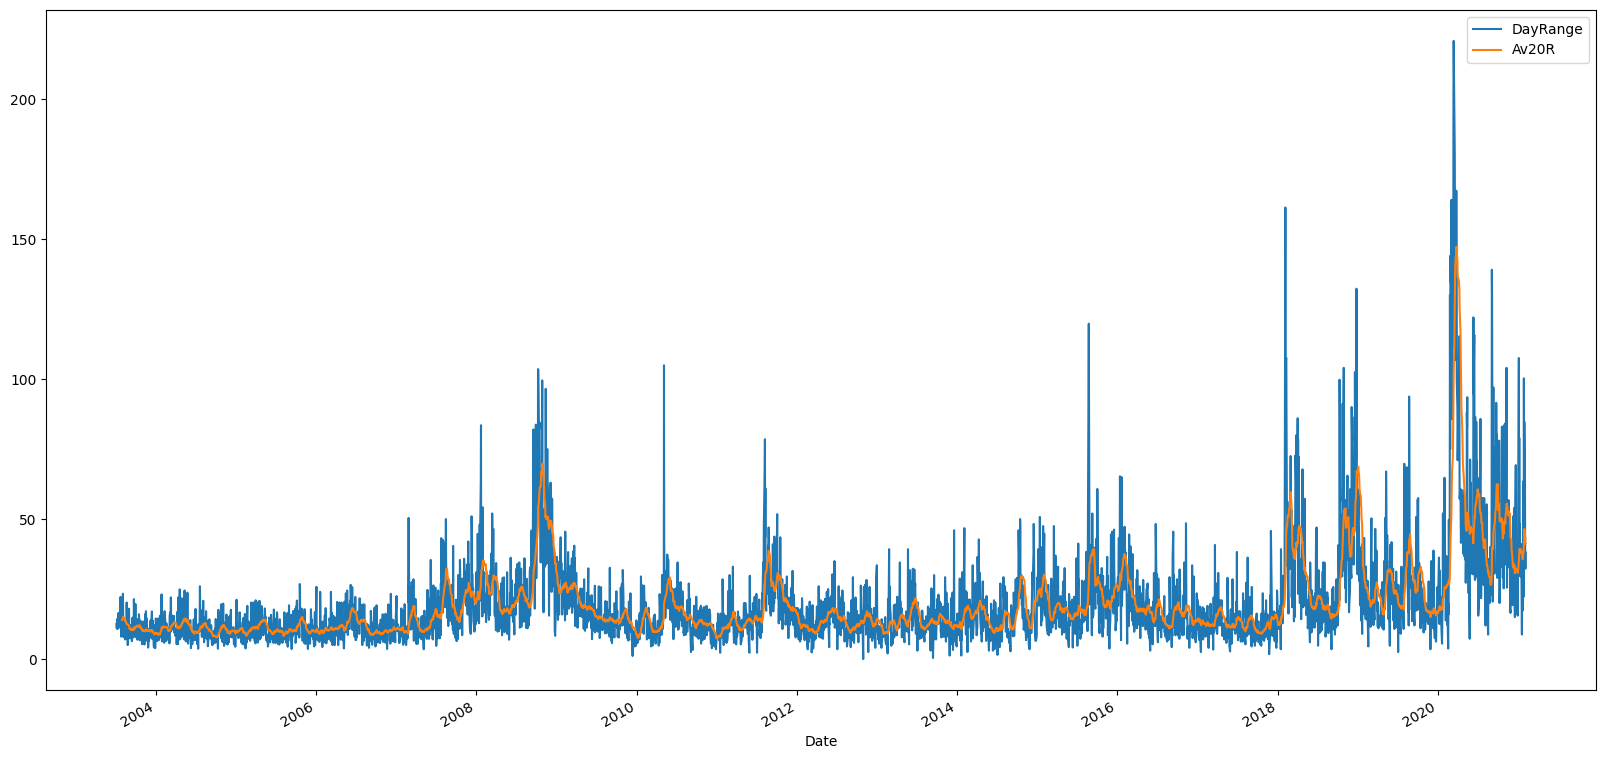

In [45]:
df.plot(x='Date', y=['DayRange','Av20R'], figsize=(20, 10));